# Machine Learning Lab 2
## Maximum Likelihood Estimation with Poisson Distribution

Makine Öğrenmesi Laboratuvar Ödevi
YZM212 – 2025/2026 Bahar Beyza Seray Seyrek/24290451

## Problem Description

The number of cars passing through a road in one minute is assumed to follow a Poisson distribution.

Our goal is to estimate the parameter λ using Maximum Likelihood Estimation (MLE).


In [ ]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.stats import poisson

traffic_data = np.array([
    12, 15, 10, 8, 14, 11, 13,
    16, 9, 12, 11, 14, 10, 15
])


## Numerical MLE Estimation


In this section we estimate the parameter λ using numerical optimization.
We minimize the Negative Log-Likelihood function.


In [ ]:
def negative_log_likelihood(lam, data):
    """
    Poisson dağılımı için negatif log likelihood hesaplar
    """

    lam = lam[0]

    # log(k!) sabit olduğu için ihmal edilebilir
    nll = -(np.sum(-lam + data * np.log(lam)))

    return nll


In [ ]:
initial_guess = [1.0]

result = opt.minimize(
    negative_log_likelihood,
    initial_guess,
    args=(traffic_data,),
    bounds=[(0.001, None)]
)

print("Numerical MLE lambda:", result.x[0])
print("Analytical lambda (mean):", np.mean(traffic_data))


Numerical MLE lambda: 12.142846011159076
Analytical lambda (mean): 12.142857142857142


## Visualization
Comparison between observed traffic data and the Poisson model.


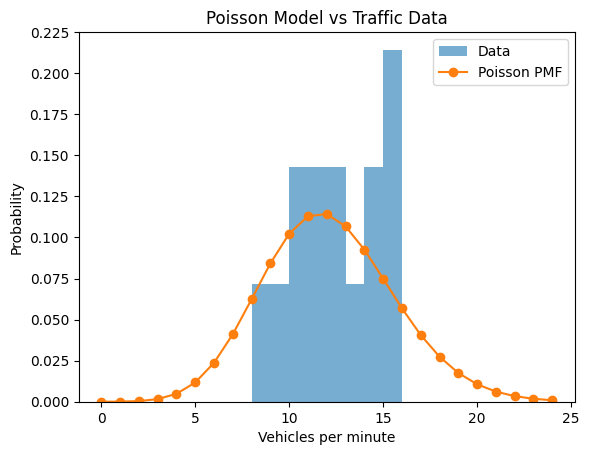

In [ ]:
lam = result.x[0]

x = np.arange(0, 25)
pmf = poisson.pmf(x, lam)

plt.hist(traffic_data, bins=8, density=True, alpha=0.6, label="Data")
plt.plot(x, pmf, 'o-', label="Poisson PMF")

plt.xlabel("Vehicles per minute")
plt.ylabel("Probability")
plt.title("Poisson Model vs Traffic Data")
plt.legend()

plt.show()


## Outlier Analysis
Effect of an extreme value on the MLE estimation.


In [ ]:
traffic_data_outlier = np.append(traffic_data, 200)

print("Original mean:", np.mean(traffic_data))
print("Mean with outlier:", np.mean(traffic_data_outlier))


Original mean: 12.142857142857142
Mean with outlier: 24.666666666666668
